[1 1 0 2 1 2 0 2 0 0 0 2 0 0 1 0 1 2 0 0 0 0 2 1 0 1 1 2 2 0 0 0 1 0 1 0 1
 2 1 2 2 0 1 2 0 0 1 2 1 2 2 1 1 0 1 2 1 0 2 0 1 2 2 1 1 2 2 1 1 0 2 1 1 0
 0 1 1 2 0 2 0 0 1 0 2 1 1 0 2 0 1 0 1 0 0 1 1 0 1 1 2 0 2 0 0 0 0 0 2 1 2
 0 0 0 0 2 1 2 1 2 2 2 0 1 1 1 1 0 1 1 0 0 0 0 0 2 2 1 0 1 0 0 1 0 2 2 2 0
 2 0 0 1 2 1 0 2 2 1 1 0 0 1 1 1 0 1 2 0 0 0 0 0 2 0 2 2 2 0 2 2 1 0 1 2 2
 1 2 0 2 2 1 1 2 1 2 2 2 2 0 1 0 0 2 2 0 2 1 1 2 0 0 1 2 2 1 1 1 1 0 1 1 2
 1 1 0 2 1 1 2 0 0 1 0 1 2 2 1 2 1 1 1 2 2 0 1 2 2 2 1 2 1 2 1 2 2 1 2 0 1
 0 0 0 1 0 2 2 1 2 2 0 0 2 2 2 1 1 1 0 0 0 2 2 2 2 1 2 1 2 2 1 0 2 2 0 1 0
 2 0 1 1]
簇内平方和SSE: 18.263159330895952
轮廓系数: 0.8482330810203894
CH指数: 4730.173967940951


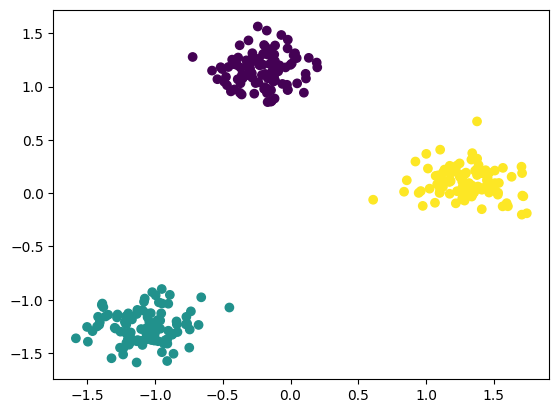

In [ ]:
# API介绍（KMeans聚类）——含详细注释与返回值类型说明

# 1. 导入所需库
from sklearn.cluster import KMeans   # KMeans聚类算法
from sklearn.datasets import make_blobs   # 用于生成模拟聚类数据
from sklearn.preprocessing import StandardScaler  # 数据标准化
from sklearn.metrics import silhouette_score, calinski_harabasz_score  # 聚类效果评价指标
import matplotlib.pyplot as plt   # 可视化

# 2. 生成模拟数据
# 返回值:
#   X: ndarray, shape(300, 2)，生成的特征数据
#   _: ndarray, shape(300, )，生成的真实标签（本例未使用）
X, _ = make_blobs(
    n_samples=300,     # 样本数量
    n_features=2,      # 特征数量
    centers=3,         # 聚类中心数量
    cluster_std=1.0,   # 簇内数据标准差（控制每个簇中数据的离散程度，数值越大簇内数据分布越分散，越小则越集中）
    random_state=42    # 随机种子，保证实验可复现
)

# 3. 数据标准化（消除量纲影响）
# sd: StandardScaler对象
# 返回值:
#   X: ndarray, shape(300, 2)，标准化后的特征数据
sd = StandardScaler()
X = sd.fit_transform(X)

# 4. 创建KMeans聚类模型
# n_clusters: 指定聚类数目
# random_state: 随机种子，保证实验可复现
# 返回值:
#   kmeans: KMeans对象（未训练）
kmeans = KMeans(n_clusters=3, random_state=42)

# 5. 训练聚类模型
# fit(X): 在数据X上构建模型
# 返回值:
#   kmeans: 拟合后的KMeans对象（可省略，也可赋值接收）
kmeans.fit(X)

# 6. 输出聚类标签
# predict(X): 预测X中每个样本的聚类标签
# 返回值:
#   labels: ndarray, shape(300, )，每个样本所属的簇标签
labels = kmeans.predict(X)
print(labels)  # 输出结果示例：[2 1 2 ... 0 1 0]

# 7. 模型评估
# kmeans.inertia_: float，所有样本点到其最近簇中心的距离之和（即SSE, 越小越好）
# silhouette_score(X, labels): float, 轮廓系数，范围[-1, 1]，越大表示聚类效果越好
# calinski_harabasz_score(X, labels): float, CH指数，越大表示聚类效果越好
print("簇内平方和SSE:", kmeans.inertia_)  # 类型: float
print("轮廓系数:", silhouette_score(X, labels))  # 类型: float
print("CH指数:", calinski_harabasz_score(X, labels))  # 类型: float

# 8. 聚类结果可视化
# plt.scatter: 绘制散点图，根据labels着色
# 返回值:
#   PathCollection对象（散点图）
plt.scatter(X[:, 0], X[:, 1], c=labels)

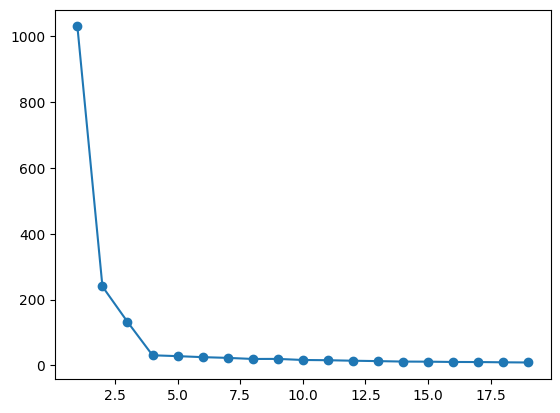

In [2]:
# K-means，使用肘部法确定K值

# 1. 导包
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

# 2. 创建数据集
X, y = make_blobs(n_samples=400, n_features=4, centers=[[-1,-1],[0,0],[1,1],[2,2]], cluster_std=0.2, random_state=42)
# plt.scatter(X[:, 0], X[:, 1])

# 3. 肘部法确定K值
SSE = []
for k in range(1, 20):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    SSE.append(kmeans.inertia_)

# 4. 绘制
plt.plot(range(1, 20), SSE, marker='o')

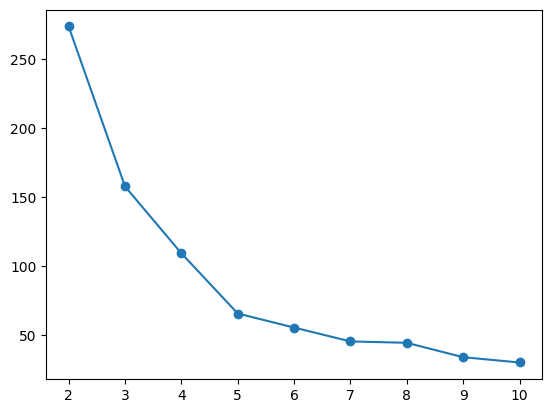

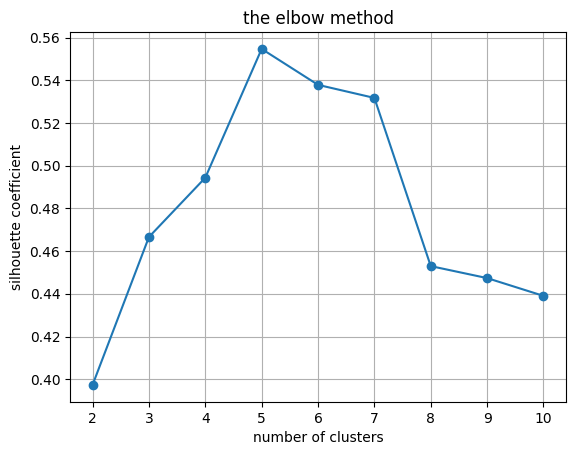

In [10]:
# 聚类，客户分析案例

# 1. 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans  # KMeans聚类器
from sklearn.preprocessing import StandardScaler  # 数据标准化工具
from sklearn.metrics import silhouette_score  # 轮廓系数评价
from sklearn.metrics import calinski_harabasz_score  # CH指标评价

# 2. 获取并读取客户数据
# 返回值: data: DataFrame, shape=(n_samples, n_features)
data = pd.read_csv('data/customers.csv')  # 从CSV文件读取数据
data.head()  # 显示前五行，便于预览数据结构

# 3. 选择需要聚类的特征
# 返回值: X: DataFrame, shape=(n_samples, 2)
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]  # 选择“年收入”和“消费评分”为聚类特征

# 4. 数据标准化处理
scaler = StandardScaler()  # 创建标准化对象
X = scaler.fit_transform(X)  # 拟合并变换数据，返回值: ndarray, shape=(n_samples, 2)

# 5. 肘部法训练模型，选择最佳K值
SSE = []  # 存储每个K下的组内平方误差SSE，类型: list of float
SC = []   # 存储每个K下的轮廓系数SC，类型: list of float
for k in range(2, 11):
    # 创建KMeans聚类器，设置k个聚类中心
    estimator = KMeans(n_clusters=k)
    # 拟合数据X进行聚类
    estimator.fit(X)
    # estimator.inertia_: 返回当前K值下的所有点到其最近中心的距离总和（SSE），类型: float
    SSE.append(estimator.inertia_)
    # silhouette_score(X, labels): 计算聚类结果的轮廓系数
    # 参数说明：
    #   X: array-like, shape = [n_samples, n_features]，表示用于聚类的标准化后的特征数据
    #   labels: array-like, shape = [n_samples]，表示聚类模型预测的每个样本点所属的类别标签
    # 返回值：
    #   silhouette coefficient（轮廓系数），类型为 float，取值范围为[-1, 1]，数值越大说明聚类效果越好
    SC.append(silhouette_score(X, estimator.labels_))

# 6. 绘制图像分析K值
# 绘制图1：SSE随聚类个数K的变化曲线，用于肘部法
# 返回值: list[matplotlib.lines.Line2D]
plt.plot(range(2, 11), SSE, 'o-')  # x轴为K值，y轴为SSE
plt.show()
# 绘制图2：轮廓系数SC随K的变化曲线，用于辅助选择最佳K
# 返回值: list[matplotlib.lines.Line2D]
plt.plot(range(2, 11), SC, 'o-')
plt.title("the elbow method")
plt.xlabel("number of clusters")
plt.ylabel("silhouette coefficient")
plt.grid()
plt.show()